# SUBGRAFOS

Juliana Lombard Souza

In [1]:
# Instalar as bibliotecas necessárias
!pip install geopandas networkx matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1 CONFIGURAÇÃO DE CAMINHOS

In [2]:
# Insira os caminhos completos para as suas pastas.
caminho_pasta_dados = r"c:/Users/Juliana/project/data" # renomeie aqui
caminho_pasta_saida = r"c:/Users/Juliana/project/output" # renomeie aqui

from pathlib import Path

# Converte as strings para objetos Path
DATA_DIR = Path(caminho_pasta_dados)
OUTPUT_DIR = Path(caminho_pasta_saida)

# Validação
if not DATA_DIR.exists():
    raise FileNotFoundError(f"ERRO: A pasta de dados especificada não existe!\nVerifique o caminho: {DATA_DIR}")

# Cria a pasta de saída se ela não existir
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define os caminhos para os arquivos
rede_shp = DATA_DIR / "rede_teste_lin.shp" # renomeie aqui
output_shp_path = OUTPUT_DIR / "rede_teste_subgrafos.shp" # renomeie aqui
output_plot_path = OUTPUT_DIR / "rede_teste_subgrafos.png" # renomeie aqui

print("Configuração de caminhos concluída com sucesso!")

Configuração de caminhos concluída com sucesso!


In [3]:
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

## 2 ANÁLISE E CLASSIFICAÇÃO

In [4]:
# 1. Carrega e limpa o shapefile
print(f"Carregando o arquivo de rede: {rede_shp}")
gdf = gpd.read_file(rede_shp)

# Limpeza de dados
initial_count = len(gdf)
gdf = gdf[gdf.geometry.notnull()]
gdf = gdf[~gdf.is_empty]
final_count = len(gdf)
if initial_count != final_count:
    print(f"Limpeza de dados: {initial_count - final_count} feições com geometria nula ou vazia foram removidas.")
print(f"Shapefile carregado com {final_count} feições válidas.")

# 2. Correção de geometrias inválidas
print("\nCorrigindo geometrias inválidas com make_valid()...")
gdf.geometry = gdf.make_valid()
print("Correção concluída.")

# 3. Construir o grafo
print("\nConstruindo o grafo da rede...")
G = nx.Graph()
for idx, line in gdf.iterrows():
    geom = line.geometry
    if geom.geom_type == 'LineString':
        start_coord = (geom.coords[0][0], geom.coords[0][1])
        end_coord = (geom.coords[-1][0], geom.coords[-1][1])
        G.add_edge(start_coord, end_coord, original_fid=idx)
    elif geom.geom_type == 'MultiLineString':
        for part in geom.geoms:
            start_coord = (part.coords[0][0], part.coords[0][1])
            end_coord = (part.coords[-1][0], part.coords[-1][1])
            G.add_edge(start_coord, end_coord, original_fid=idx)

# 4. Encontrar componentes e classificar
components = list(nx.connected_components(G))
print(f"\nA rede viária possui {len(components)} componente(s) conectado(s).")

if not components:
    print("O grafo está vazio.")
else:
    largest_component_nodes = max(components, key=len)
    print(f"O componente principal tem {len(largest_component_nodes)} nós.")

    print("\nIniciando a classificação dos subgrafos...")
    gdf['subgrafo'] = 0
    subgraph_components = [comp for comp in components if comp != largest_component_nodes]
    subgraph_sizes = []
    for comp_nodes in subgraph_components:
        edge_count = sum(1 for u, v, data in G.edges(data=True) if u in comp_nodes and v in comp_nodes)
        subgraph_sizes.append((comp_nodes, edge_count))
    subgraph_sizes.sort(key=lambda x: x[1], reverse=True)

    subgraph_id = 1
    for comp_nodes, size in subgraph_sizes:
        print(f"  -> Classificando Subgrafo {subgraph_id} com {size} trechos...")
        subgraph_fids = {data['original_fid'] for u, v, data in G.edges(data=True) if u in comp_nodes and v in comp_nodes}
        gdf.loc[gdf.index.isin(subgraph_fids), 'subgrafo'] = subgraph_id
        subgraph_id += 1
    print("Classificação concluída.")

    # 5. Salvar resultado
    print(f"\nSalvando o arquivo classificado em: {output_shp_path}")
    gdf.to_file(output_shp_path)
    print("--- Análise Concluída com Sucesso! ---")

Carregando o arquivo de rede: c:\Users\Juliana\project\data\rede_teste_lin.shp
Shapefile carregado com 13392 feições válidas.

Corrigindo geometrias inválidas com make_valid()...
Correção concluída.

Construindo o grafo da rede...

A rede viária possui 16 componente(s) conectado(s).
O componente principal tem 5780 nós.

Iniciando a classificação dos subgrafos...
  -> Classificando Subgrafo 1 com 3301 trechos...
  -> Classificando Subgrafo 2 com 2215 trechos...
  -> Classificando Subgrafo 3 com 4 trechos...
  -> Classificando Subgrafo 4 com 1 trechos...
  -> Classificando Subgrafo 5 com 1 trechos...
  -> Classificando Subgrafo 6 com 1 trechos...
  -> Classificando Subgrafo 7 com 1 trechos...
  -> Classificando Subgrafo 8 com 1 trechos...
  -> Classificando Subgrafo 9 com 1 trechos...
  -> Classificando Subgrafo 10 com 1 trechos...
  -> Classificando Subgrafo 11 com 1 trechos...
  -> Classificando Subgrafo 12 com 1 trechos...
  -> Classificando Subgrafo 13 com 1 trechos...
  -> Classific

## 3 VISUALIZAR O RESULTADO

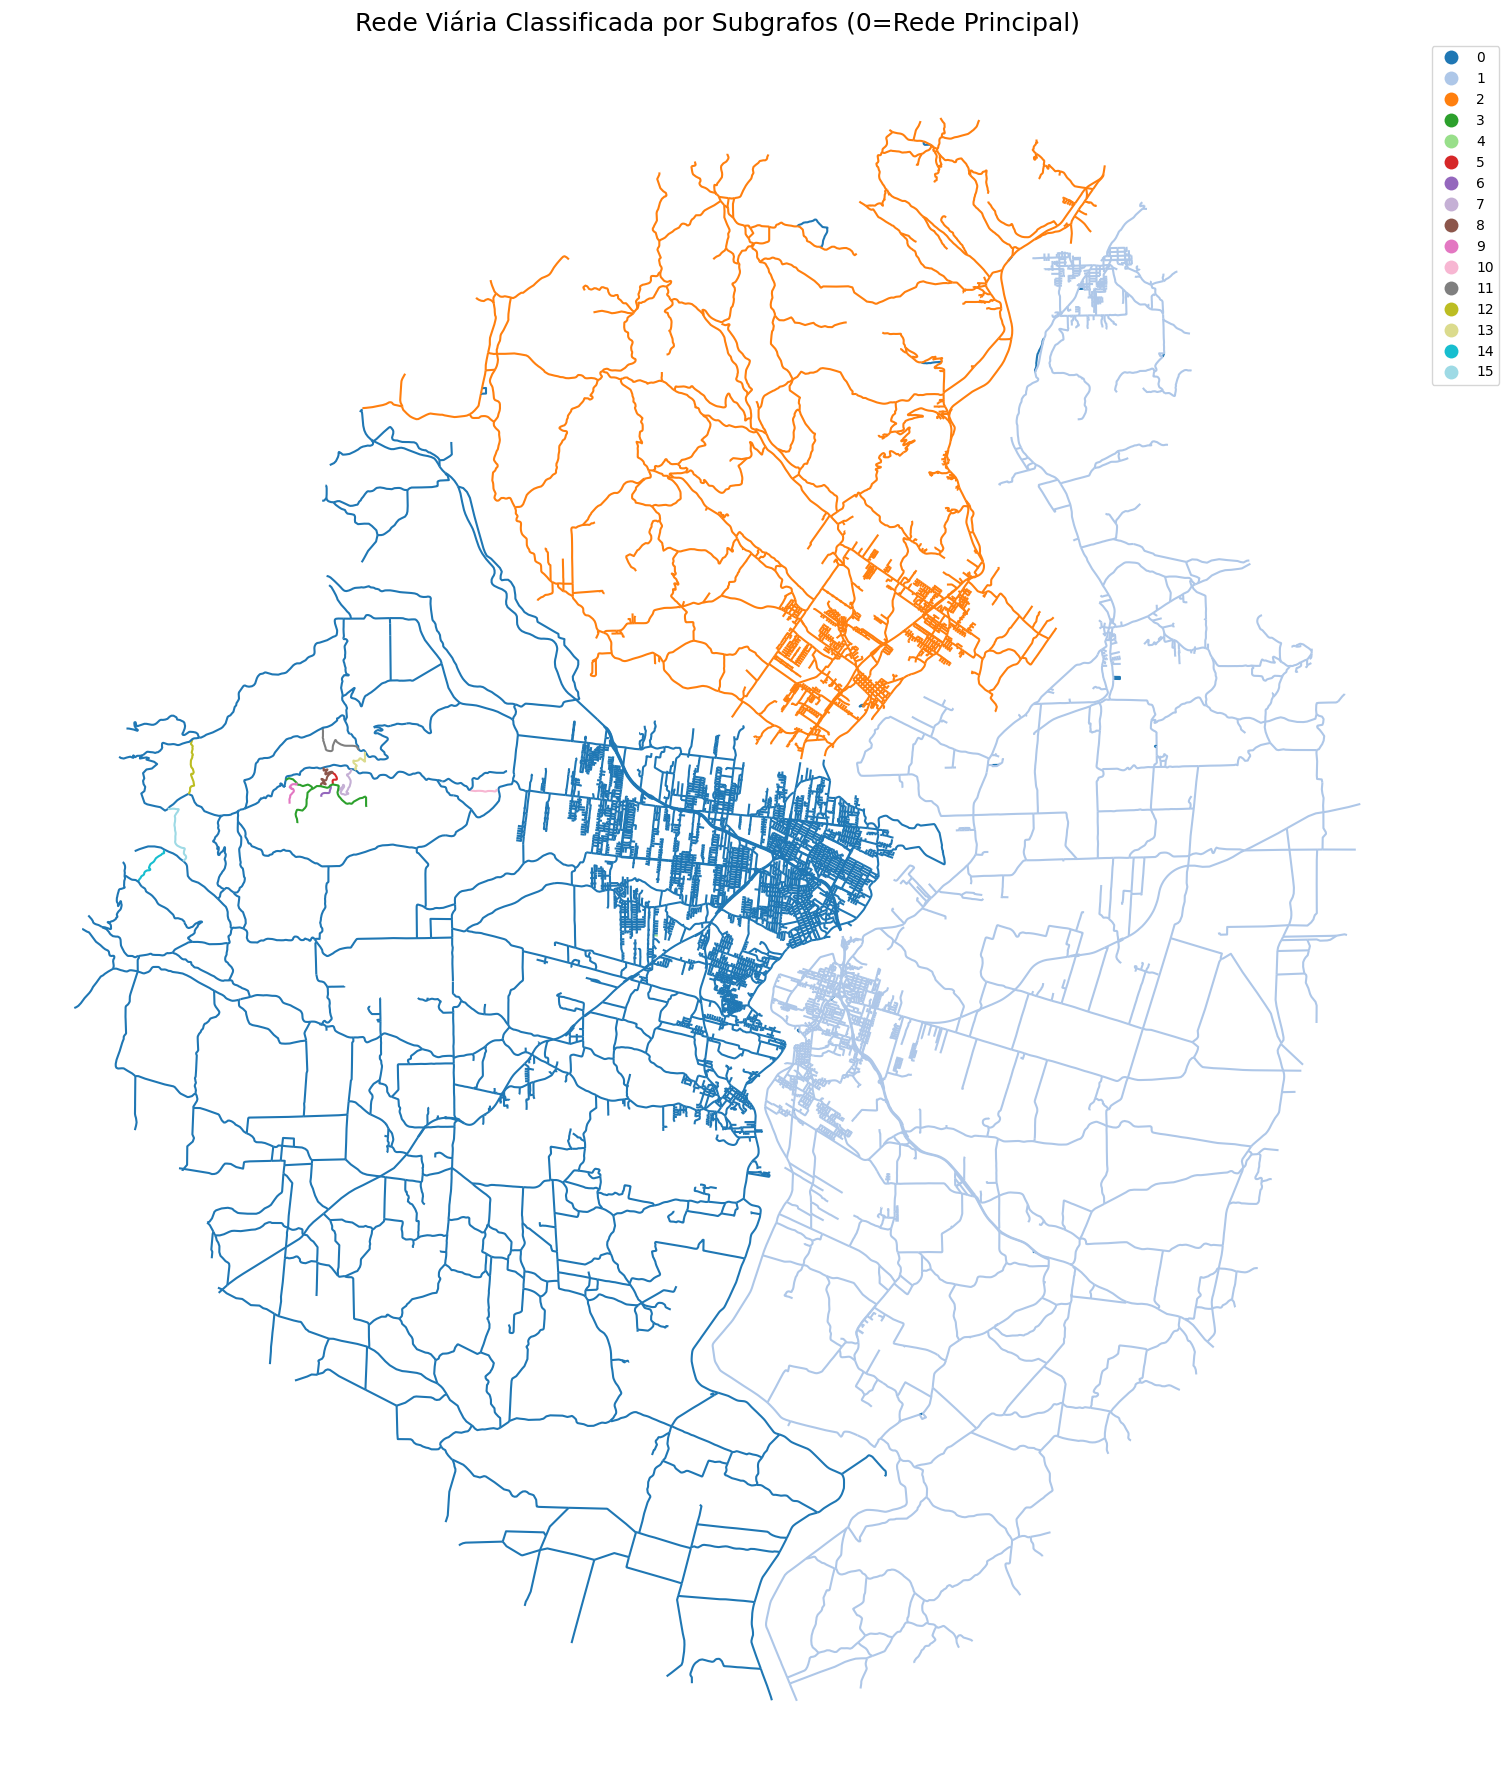


Resumo da Classificação (quantidade de trechos por subgrafo):
subgrafo
0     7860
1     3301
2     2215
3        4
4        1
5        1
6        1
7        1
8        1
9        1
10       1
11       1
12       1
13       1
14       1
15       1
Name: count, dtype: int64


In [5]:
# Visualizar o resultado
fig, ax = plt.subplots(1, 1, figsize=(18, 18))
gdf.plot(ax=ax, column='subgrafo', cmap='tab20', legend=True, categorical=True, linewidth=1.5,
         legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})
ax.set_title('Rede Viária Classificada por Subgrafos (0=Rede Principal)', fontsize=18)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(output_plot_path) # Salva o mapa na pasta de saída
plt.show()

# Exibe um resumo
print("\nResumo da Classificação (quantidade de trechos por subgrafo):")
print(gdf['subgrafo'].value_counts().sort_index())